In [1]:
import pandas as pd 
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
commits = pd.read_sql(""" 
SELECT timestamp
FROM checker
WHERE uid LIKE "user_%"
""", conn)

In [4]:
commits['timestamp'] = pd.to_datetime(commits['timestamp'])

commits['date'] = commits['timestamp'].dt.date
commits['day_of_week'] = commits['timestamp'].dt.dayofweek
commits['hour'] = commits['timestamp'].dt.hour

In [5]:
commits.head()

,timestamp,date,day_of_week,hour
0,2020-04-17 05:19:02.744528,2020-04-17,4,5
1,2020-04-17 05:22:35.249331,2020-04-17,4,5
2,2020-04-17 05:22:45.549397,2020-04-17,4,5
3,2020-04-17 05:34:14.691200,2020-04-17,4,5
4,2020-04-17 05:34:24.422370,2020-04-17,4,5


In [6]:
weekend = commits[commits['day_of_week'].isin([5,6])].reset_index()
working_day = commits[~commits['day_of_week'].isin([5,6])].reset_index()

In [7]:
working_day.head()

,index,timestamp,date,day_of_week,hour
0,0,2020-04-17 05:19:02.744528,2020-04-17,4,5
1,1,2020-04-17 05:22:35.249331,2020-04-17,4,5
2,2,2020-04-17 05:22:45.549397,2020-04-17,4,5
3,3,2020-04-17 05:34:14.691200,2020-04-17,4,5
4,4,2020-04-17 05:34:24.422370,2020-04-17,4,5


In [8]:
workday_counts = working_day.groupby(['date', 'hour']).size().reset_index(name='commits')
weekend_counts = weekend.groupby(['date', 'hour']).size().reset_index(name='commits')

In [9]:
workday_counts.head()

,date,hour,commits
0,2020-04-17,5,13
1,2020-04-17,11,8
2,2020-04-17,12,2
3,2020-04-20,11,2
4,2020-04-20,14,3


In [10]:
workday_avg = workday_counts.groupby('hour')['commits'].mean().reset_index(name='working_day')
weekend_avg = weekend_counts.groupby('hour')['commits'].mean().reset_index(name='weekend')

In [11]:
workday_avg[workday_avg['hour'] == 17]

,hour,working_day
14,17,16.0


In [12]:
weekend_avg[weekend_avg['hour'] == 17]

,hour,weekend
14,17,7.142857


In [13]:
all_hours = pd.DataFrame({'hour':range(24)})

In [14]:
workday_full = all_hours.merge(workday_avg, on='hour', how='left')
workday_full.fillna(0, inplace=True)

In [15]:
weekend_full = all_hours.merge(weekend_avg, on='hour', how='left')
weekend_full.fillna(0,inplace=True)

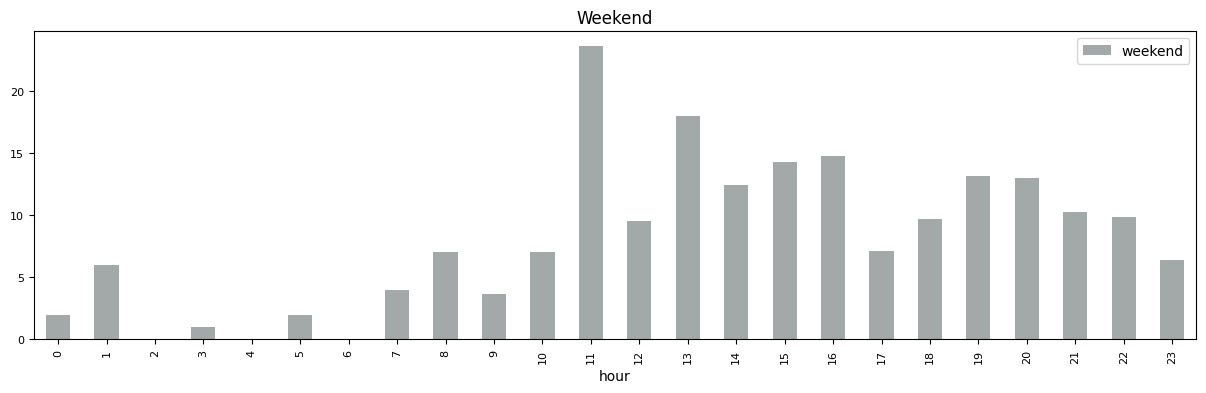

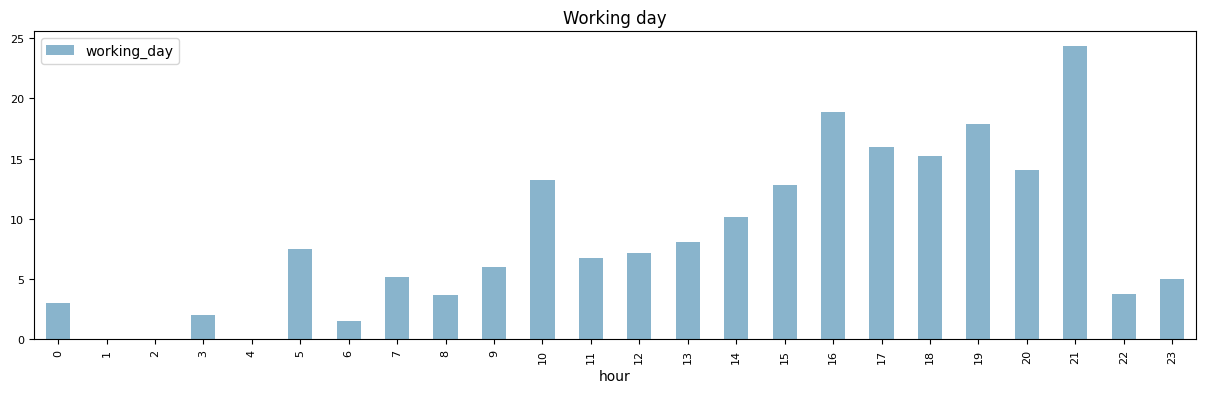

In [16]:
# Выходные
ax2 = weekend_full.plot(
    kind='bar',
    x='hour',
    y='weekend',
    color="#A3A8A9",
    figsize=(15, 4),
    legend=True,
    title='Weekend',
    fontsize=8
)
ax2.set_xlabel('hour')

# Рабочие дни
ax1 = workday_full.plot(
    kind='bar',
    x='hour',
    y='working_day',
    color="#89B4CC",
    figsize=(15, 4),
    legend=True,
    title='Working day',
    fontsize=8
)


<h2>Отличается ли динамика в рабочие и выходные дни</h2>

In [17]:
print(workday_full.loc[workday_full['working_day'].idxmax(), 'hour'])

21


In [18]:
print(weekend_full.loc[weekend_full['weekend'].idxmax(), 'hour'])

11


In [19]:
conn.close()